# Small-sized Inversions
Here, we visualize the inversions that were identified for the `small` treatment across the range of depths.

In [16]:
library(ggplot2)
options(warn = -1)
read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    axis_ticks <- c(paste0("sample_", sprintf("%02d", 1:10), ".", depth), "simulated_inversions")
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"small"` to avoid writing it each time

In [17]:
.size <- "small"

## 0.5X depth

In [18]:
depth_05X <- read_data(.size, "05X")
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
16,3L,4085868,4090818,simulated_inversions
17,3L,14492093,14496538,simulated_inversions
18,3L,17994845,18016735,simulated_inversions
19,3L,24140993,24156318,simulated_inversions
20,3L,26678791,26687230,simulated_inversions
21,2L,13024403,13026577,pooled_05X_small


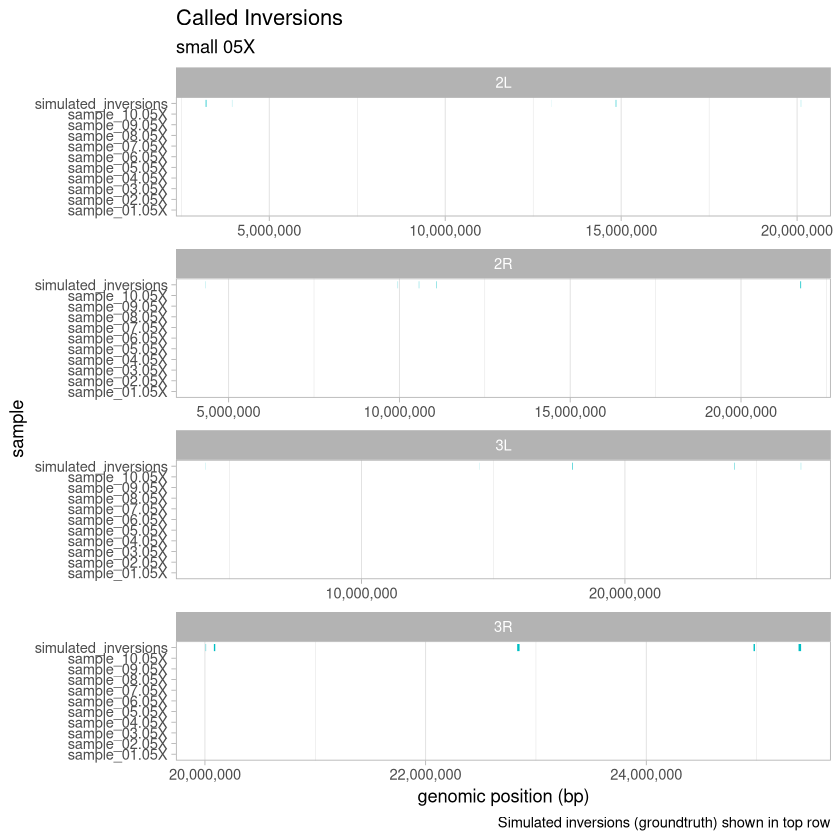

In [19]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [20]:
depth_2X <- read_data(.size, "2X")
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
58,2R,11083685,11094907,pooled_2X_small
59,2R,21736723,21759356,pooled_2X_small
60,3R,20006863,20010483,pooled_2X_small
61,3R,20081036,20093594,pooled_2X_small
62,3R,22829881,22851519,pooled_2X_small
63,3R,24971984,24984761,pooled_2X_small


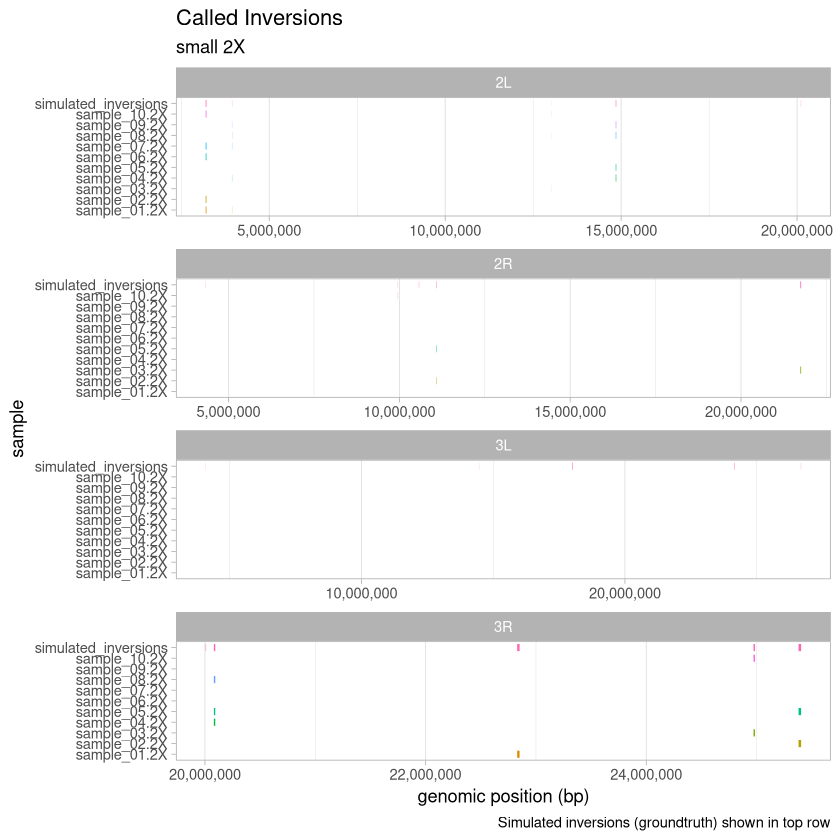

In [21]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [22]:
depth_5X <- read_data(.size, "5X")
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
124,2R,21736721,21759356,pooled_5X_small
125,3R,20006863,20010483,pooled_5X_small
126,3R,20081036,20093594,pooled_5X_small
127,3R,22829881,22851520,pooled_5X_small
128,3R,24971984,24984761,pooled_5X_small
129,3R,25379866,25402914,pooled_5X_small


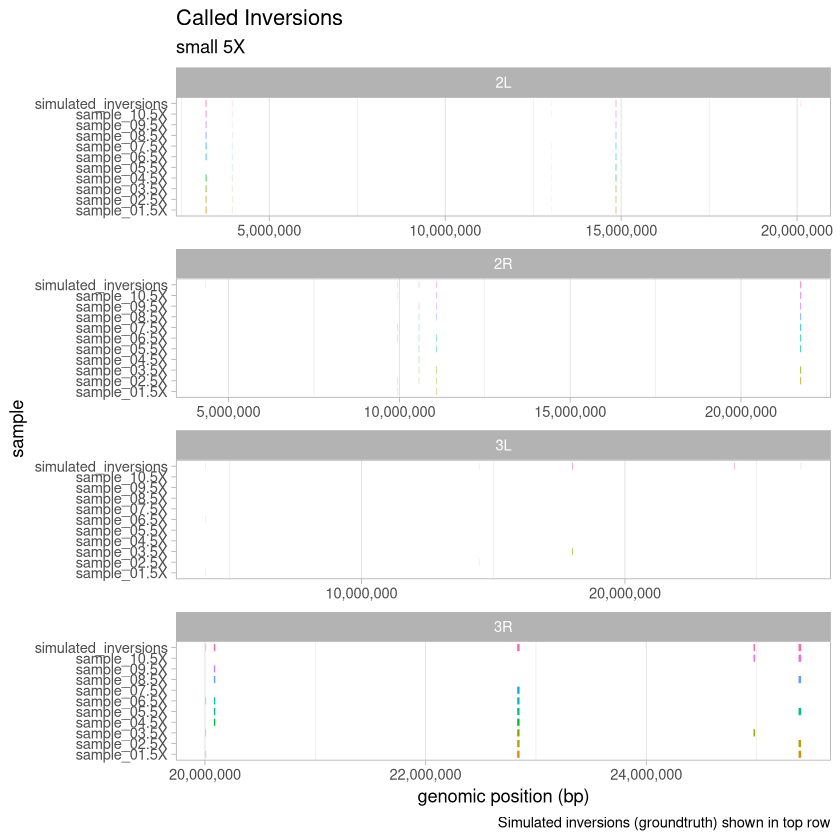

In [23]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [24]:
depth_10X <- read_data(.size, "10X")
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
146,2R,21736721,21759356,pooled_10X_small
147,3R,20006863,20010483,pooled_10X_small
148,3R,20081036,20093594,pooled_10X_small
149,3R,22829881,22851519,pooled_10X_small
150,3R,24971984,24984761,pooled_10X_small
151,3R,25379866,25402914,pooled_10X_small


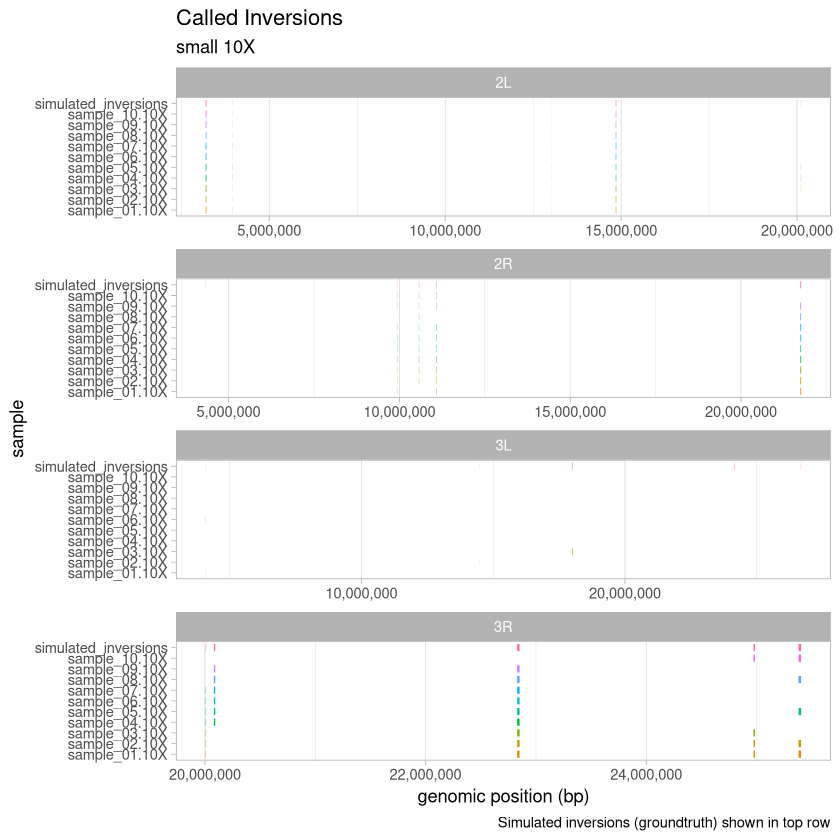

In [25]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [26]:
depth_20X <- read_data(.size, "20X")
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
155,2R,21736721,21759356,pooled_20X_small
156,3R,20006863,20010483,pooled_20X_small
157,3R,20081036,20093594,pooled_20X_small
158,3R,22829881,22851519,pooled_20X_small
159,3R,24971984,24984761,pooled_20X_small
160,3R,25379866,25402914,pooled_20X_small


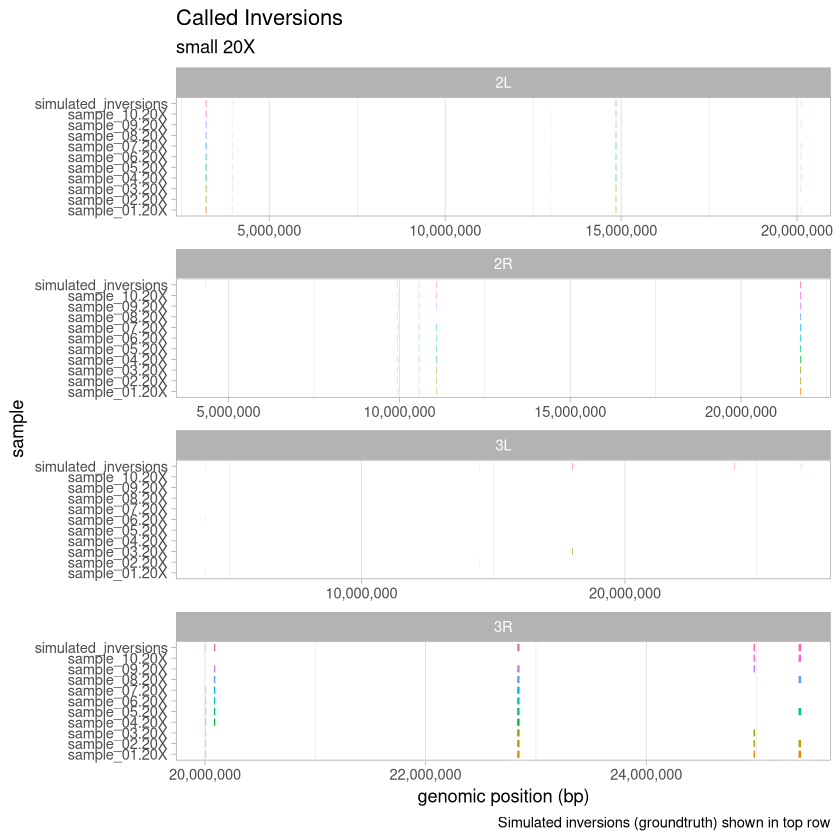

In [27]:
plot_data(depth_20X, .size, "20X")